# Linear discriminant analysis

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Understand and be able to implement and use LDA;
- Understand assumptions and limitations of LDA;
- Be able to provide solution to common issues of LDA.

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


In [2]:
import os
import mne

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

## Exercise 1: train LDA
In the first exercise, you will implement LDA from scratch using plain numpy. We will later train and test it with the Iris dataset, and compare it to the implementation from the "sklearn" library.
1. Provide the equations to train the weights and bias of LDA in LaTeX. (You can use LaTeX in Markdown by surrounding your formula with \$\$); 
1. Write the function `train_lda(X, y)` that accepts the data $X$ of dimensionality $N_{samples} \times D_{features}$ and the labels $y$, a vector of $N_{samples}$ containing integer class labels. The function should output the weights and bias. Note, we assume a binary classification problem.

In [2]:
# Answer here

Solution:

$\mathbf{w} = \mathbf{\Sigma_W^{-1}}(\mathbf{\boldsymbol{\mu_2}} - \mathbf{\boldsymbol{\mu_1}})$ or notation from slides: $\mathbf{w} = \mathbf{S_W^{-1}}(\mathbf{m_2} - \mathbf{m_1})$

$b = -\frac{1}{2}\mathbf{w}^T(\boldsymbol{\mu_2} + \boldsymbol{\mu_1})$ or notation from slides: $b = -\frac{1}{2}\mathbf{w}^T(\mathbf{m_1} + \mathbf{m_2})$

Preferably with the correct use of bold symbols.

In [3]:
# Solution

def train_lda(X, y):
    classes = np.unique(y) # allows arbitrary class labels
    means = []
    covs = []
    for i in range(classes.size): # assumed two-class
        idx = y == classes[i]
        means.append(np.mean(X[idx, :], axis=0))
        covs.append(np.cov(X[idx, :].transpose()))
    weights = np.dot(np.linalg.pinv(0.5 * (covs[0] + covs[1])), (means[1] - means[0]))
    bias = -0.5 * np.dot(weights, (means[0] + means[1]))    
    return weights, bias


## Exercise 2: apply LDA
The next step is to implement the routine to apply LDA to new data (i.e., validation/test data). 
1. Provide the equations to apply LDA to new data using the weights and bias in LaTeX;
1. Write a function `apply_lda(X, weights, bias)` that accepts the weights and bias to classify data $X$ of dimensionality $N_{samples} \times D_{features}$. It should output predicted labels, one for each sample in $X$.

In [4]:
# Answer here

In [5]:
# Solution

def apply_lda(X, weights, bias):
    yh = 1 + (np.sign(np.dot(X, weights.T) + bias) + 1) / 2       
    return yh


## Exercise 3: classify the Iris dataset
Now it is time to test your implementation. For this we use the well-known Iris dataset. We provide some code below to download this data from the "pandas" library using `datasets.load_iris()`. Many more standard datasets exist there for quick testing and benchmarking. Pandas uses so called 'dataframes' that are easily interpreted by "seaborn", that has a nice built-in function `pairplot()` to visualize the features. For this assignment, we will restrict the dataset to only two classes.

Your tasks:
1. Train and apply your LDA and compute the classification accuracy.
1. Train and apply the LDA from sklearn (`LDA()`), and compare its classification accuracy to yours. 

Number of features:  4
Number of train examples:  80
Number of valid examples:  20


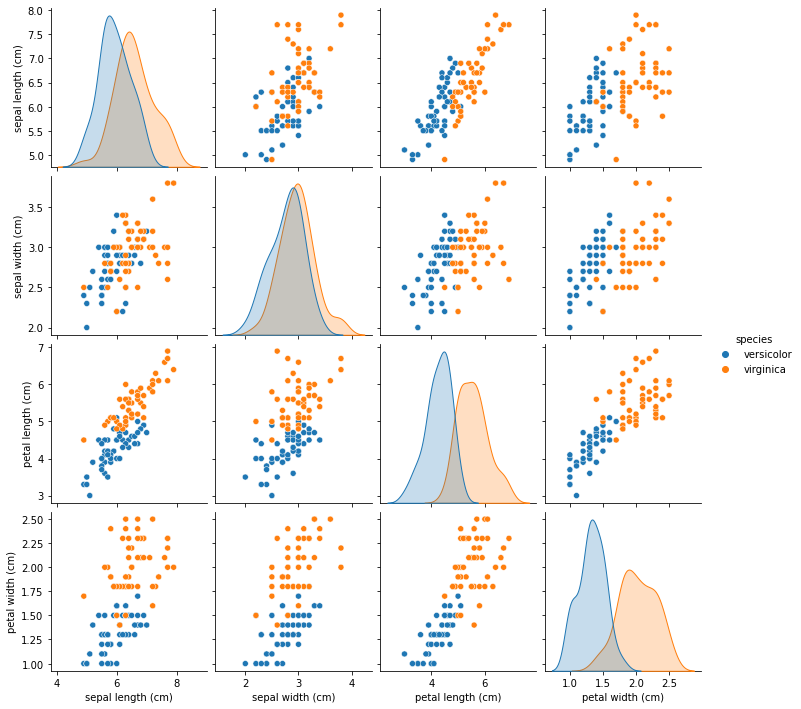

In [6]:
# Load Iris dataset and select 2 classes
iris = datasets.load_iris()
labels = [1, 2]
idx = np.logical_or(iris.target == labels[0], iris.target == labels[1])
iris.data = iris.data[idx, :]
iris.target = iris.target[idx]

# Make a pandas dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target_names[iris.target]

# Plot data
sns.pairplot(df, hue="species")

# Split data
X_train, X_valid, y_train, y_valid = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)
print("Number of features: ", X_train.shape[1])
print("Number of train examples: ", X_train.shape[0])
print("Number of valid examples: ", X_valid.shape[0])


In [7]:
# Answer here

In [8]:
# Solution

# 1. own LDA
weights, bias = train_lda(X_train, y_train)
yh = apply_lda(X_valid, weights, bias)
print("Accuracy validation: {:.2f}%".format(np.mean(yh == y_valid) * 100))

# 2. sklearn LDA
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))

Accuracy validation: 80.00%
Accuracy validation: 80.00%


## Exercise 4: preprocess features
Sometimes, some of the features clearly violate the **linear separability** assumption made by LDA. In that case, features can be pre-processed by applying a given function to each feature, which yields a Generalized Linear Discriminant analysis:

$$ y = \sum_i^D w_i f_i(\mathbf{x}_i) $$ 

We provide a dataset below, please inspect it.

Your tasks:
1. Which LDA assumption(s) are violated by the provided dataset?
1. In which way can the feature(s) be preprocessed in order to improve the performance? Hint: Think of polynomials, trigonometric functions, logarithms, exponential functions, etc.;
1. Apply your preprocessing idea to the data;
1. Visualize the preprocessed data;
1. Classify the preprocessed data using sklearn's `LDA()`. Did it improve?

Accuracy validation: 65.00%


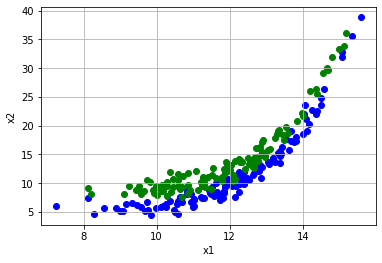

In [9]:
# (1) load data
ds_data = 'data/non-lin_train.data'
ds_labels ='data/non-lin_train.labels'
X = np.loadtxt(ds_data)
y = np.loadtxt(ds_labels)
n_samples = y.size

# (2) split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# (3) scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1] ,color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# (4) classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


In [10]:
# Answer here

Accuracy validation: 76.67%


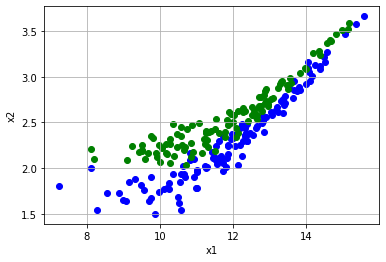

In [11]:
# Solution

# 1. assumptions
# The dataset violates the Gaussianity distribution of the features, as seen by the exponential behavior 
# of feature x2.

# 2. preprocessing
# A first approach can be applying a logarithmic function in order to get rid of the exponential behavior 
# of feature x2.

# 3. Preprocess
X_train[:, 1] = np.log(X_train[:, 1])
X_valid[:, 1] = np.log(X_valid[:, 1])

# 4. Plot preprocessed
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1] ,color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# 5. Classify preprocessed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


## (Optional) Exercise 5: extract features
Below we provide another dataset. There appears to be some exploitable structure in this data, but the LDA is not directly able to capture this.

Your tasks:
1. Which LDA assumption(s) are violated by the provided dataset?
1. In what way can the existing features be combined in order to get a proper dataset? **Hint:** Try to think of it in a 3D way: How would you add another dimension such that the 2 classes can be separated?
1. Implement your additional feature that combines the existing features;
1. Visualize the new feature using a histogram;
1. Calculate the performance of LDA using this additional feature and see if you can improve upon the performance.

Accuracy validation: 26.67%


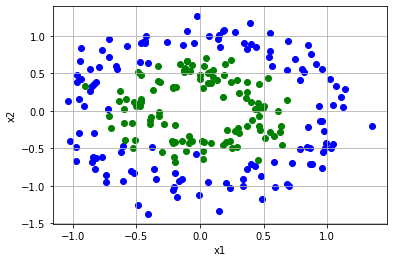

In [12]:
# (1) load data
ds_data = 'data/circles_train.data'
ds_labels ='data/circles_train.labels'
X = np.loadtxt(ds_data)
y = np.loadtxt(ds_labels)
n_samples = len(y)

# (2) split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# (3) scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1] ,color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# (4) classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


In [13]:
# Answer here

Accuracy validation: 95.00%


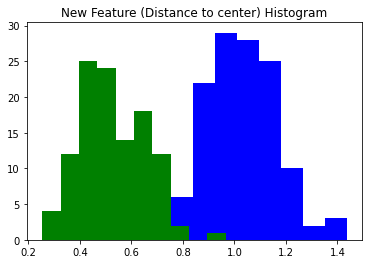

In [14]:
# Solution

# 1. assumptions
# The dataset violates the Gaussianity distribution of the features, as there are no datapoints in the middle.
# In addition, the covariance matrix of the blue class seems to be the scaled covariance matrix of the green class. They are thus not equal.

# 2. new feature
# The distance between each point and the center of the distribution acts as a feature that makes the 
# problem linearly separable. Note, this can also be achieved by taking the eccentricity in polar coordinates.

# 3. add feature
feat_new = np.atleast_2d(np.linalg.norm(X_train, axis=1)).T
X_train = np.append(X_train, feat_new, axis=1)
feat_new = np.atleast_2d(np.linalg.norm(X_valid, axis=1)).T
X_valid = np.append(X_valid, feat_new, axis=1)

# 4. plot preprocessed
plt.figure()
plt.title('New Feature (Distance to center) Histogram')
plt.hist(X_train[y_train==0, -1], bins=10, color='b');
plt.hist(X_train[y_train==1, -1], bins=10, color='g');

# 5. classify processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


## (Optional) Exercise 6: other LDA-like algorithms
Below we provide another dataset, that again is problematic for standard LDA.

Your tasks:
1. What LDA assumption(s) are violated by the next dataset?
1. What would be an optimal decision boundary? Optional: Find out which method would be able to provide this optimal decision boundary. **Hint:** It is slightly more general than the LDA algorithm;
1. Implement this improvement and verify whether it indeed improves classification of this dataset.

Accuracy validation: 88.33%


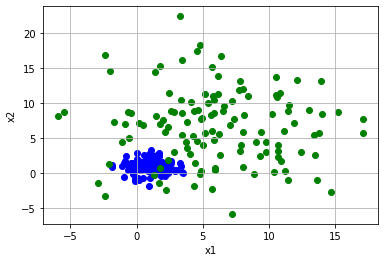

In [15]:
# (1) load data
ds_data = 'data/unbalanced_train.data'
ds_labels ='data/unbalanced_train.labels'
X = np.loadtxt(ds_data)
y = np.loadtxt(ds_labels)
n_samples = len(y)

# (2) split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# (3) scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1] ,color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# (4) classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


In [16]:
# Answer here

In [17]:
# Solution

# 1. assumptions
# The dataset violates the assumption of equal covariance matrix for both classes. 

# 2. solution
# In this case, the use of Quadratic Discriminant Analysis (QDA) provides an optimal 
# decision boundary because it drops the assumption of equal covariance matrices for both classes.

# implement a QDA classifier
clf = QDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))

Accuracy validation: 95.00%


## Exercise 7: Apply LDA to EEG data
Now you will try a simple decoding on EEG data. For this, we will make use of one of mne's standard data sets, which you will already know from assignment 1 - but we just load a version resampled to `30Hz`.

The data we load is the so called `raw` data, which we will slice to epochs depending on markers relative to the start of the recording of the raw file. Each epoch should range from -200ms to +800ms around the epoch start marker. Of course you could just make use of `mne`'s build in functions. But for now please operate on the plain numpy array of the raw data. This will ensure, that you are aware of the notion of `epoch` vs `raw` data.

We need this epoch structure as EEG experiments are usually designed to produce one label per epoch. Hence an epoch is our basic "record" unit.

**Question**:
1. Slice the raw data to epochs.
1. After step 1. your data should be in shape of [n_epochs x n_channels x n_times]. The next step is to stack the channel dimension in order to be able to use the data in a standard `sklearn` LDA classifier. Transform the epoched data to [n_epochs x n_channels * n_times]
1. Use the first 100 epochs to train an LDA classifier and report the accuracy of classifying
   the left over epochs as test set.
1. *Optional*: Why will the classifier just perform very poorly in terms of accuracy?

In [55]:
# Prepare data and the classifier

# the raw data
raw = mne.io.read_raw('./data/sample_audvis_rsampl30Hz_raw.fif')
Xraw = raw.get_data()

# markers == labels (not always the case that all markers are labels, but its valid here)
mrks = np.load('./data/events.npy', allow_pickle=True)
mp = {1: 'left_auditory', 2: 'right_auditory'}
mrks_t = mrks[:, 0]
y = [mp[e] for e in mrks[:, 1]]

# the classifier
clf = LDA()

Opening raw data file ./data/sample_audvis_rsampl30Hz_raw.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 60)  idle
    Range : 1289 ... 9619 =     42.967 ...   320.633 secs
Ready.


In [56]:
# Answer:
sfreq = raw.info['sfreq']

# First we transform the epoch start time stamps to sample point indeces
mrks_idx = np.asarray(mrks_t * sfreq, dtype=int)
print(mrks_idx)

# we know we should have -200ms to +800ms around the epoch start marker -> calc the needed shifts in sample points.
dtmin_idx = int(0.2 * sfreq)     # note, we will subtract this, so no `-` here
dtmax_idx = int(0.8 * sfreq)

# Create the epochs tensor [n_epochs x n_channels x n_times] - after this, the first dimension of
# the tensor matches with the labels first dimension
Xepo = np.asarray([
    Xraw[:, idx - dtmin_idx:idx + dtmax_idx] for idx in mrks_idx
])
print(f"{Xepo.shape=}")

# Now we reshape
X = Xepo.reshape(Xepo.shape[0], -1)
print(f"{X.shape=}")

[1397 1437 1481 1521 1560 1603 1645 1684 1725 1770 1809 1848 1893 1933
 1975 2018 2061 2104 2187 2230 2272 2310 2352 2392 2433 2471 2511 2550
 2591 2631 2672 2713 2752 2791 2833 2878 2919 3003 3048 3090 3131 3173
 3216 3256 3300 3345 3430 3469 3509 3553 3596 3637 3682 3723 3800 3841
 3880 3923 3964 4006 4047 4091 4131 4174 4218 4260 4301 4344 4382 4425
 4470 4516 4555 4597 4678 4722 4767 4811 4856 4900 4940 4984 5026 5068
 5109 5154 5196 5240 5282 5325 5362 5403 5481 5523 5566 5609 5651 5692
 5731 5775 5820 5859 5937 5978 6020 6063 6104 6147 6190 6235 6279 6320
 6360 6397 6439 6480 6518 6556 6597 6642 6729 6769 6807 6849 6892 6934
 6979 7023 7070 7153 7196 7238 7275 7319 7365 7407 7450 7491 7536 7573
 7613 7652 7696]
Xepo.shape=(143, 59, 30)
X.shape=(143, 1770)


In [58]:
# Perform the classification
X_train, y_train = X[:100], y[:100]
X_test, y_test = X[100:], y[100:]

clf.fit(X_train, y_train)
score = clf.score(X_test, y_test)
print(f"Accuracy {score:.2%}")

# The classifier performs very poorly as the number of features == 1770 is very large
# compared to the number of training samples == 143. The fitted model will not be able to generalize
# due to this imbalance.

Accuracy 53.49%


## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.